### CSV Course Specifications

This is a demonstration of the course specifications linear regression algorithm using a CSV for input. This allows students to use larger data sets.

This can also be viewed as a Python script in [5.export_import.py](5.export_import.py.) and [5.test_import.py](5.test_import.py).

#### Step 1

Load the required dependencies including [pickle](https://docs.python.org/3/library/pickle.html) the native Python library for serialising data objects:

> [!Caution]
> The pickle module is not secure. Only unpickle data you trust.

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LogisticRegression
import pickle

####  Step 2
- Open and parse the CSV file and store the data as variable array objects.

In [2]:
training_data = pd.read_csv('2.4.1.testing_data.csv', delimiter=',')
x = np.array(training_data['GoldXpAdvantage']).reshape(-1, 1)
y = np.array(training_data['blueWin'])

#### Optional Step

Apply your Python skills and query the data set about how many training examples there are and inspect a sample of the data.

In [3]:
m = len(x)
print(f"Number of training examples is: {m}")
table = pd.DataFrame({
    training_data.columns[0]: x.flatten(),  # Flatten x for easy display
    training_data.columns[1]: y
})
print(table.head())

Number of training examples is: 6009
   GoldXpAdvantage  KillDiff
0          -0.1877         0
1           0.1754         0
2          -0.1345         0
3           0.1311         1
4           0.2707         1


#### Optional Step

Plot the feature `x` and target `y` data on a graph using the column headings as the graph labels.

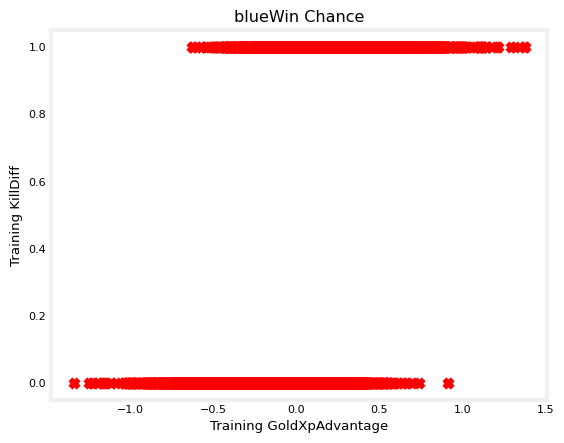

In [4]:
# Plot the data points
plt.scatter(x, y, marker='x', c='r')
# Set the title
plt.title("blueWin Chance")
# Set the y-axis label
plt.ylabel(f'Training {training_data.columns[1]}')
# Set the x-axis label
plt.xlabel(f'Training {training_data.columns[0]}')
plt.show()

#### Step 3

Use the [sklearn](https://scikit-learn.org/stable/) library to fit the model to the training data which will provide a line of best fit with the lowest cost based on a [sklearn](https://scikit-learn.org/stable/) algorithm.

In [5]:
# Create the model
my_model = LogisticRegression()
# Fit the model to the data
my_model.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Step 4

Save the model to file.

In [6]:
# save the model to disk
filename = 'my_saved_model.sav'
pickle.dump(my_model, open(filename, 'wb'))

#### Step 5
In a separate Python implementation import the file and make a prediction.

In [7]:
filename = 'my_saved_model.sav'
loaded_model = pickle.load(open(filename, 'rb'))
predict = np.array([1]).reshape(1, -1)
result = loaded_model.predict(predict)
print(result[0])

1


#### Optional Step

Plot the features, targets and model (linear regression).

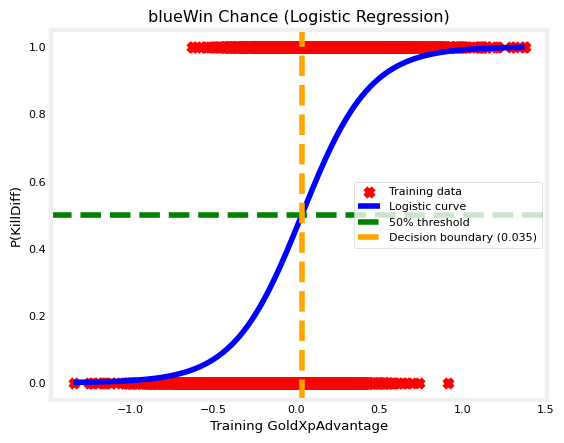

In [8]:
# Generate logistic regression line
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_prob = my_model.predict_proba(x_range)[:, 1]

# Find decision boundary
decision_boundary = -my_model.intercept_[0] / my_model.coef_[0][0]

plt.scatter(x, y, marker="x", c="r", label="Training data")
plt.plot(x_range, y_prob, c="blue", label="Logistic curve")
plt.axhline(y=0.5, color="green", linestyle="--", label="50% threshold")
plt.axvline(
    x=decision_boundary,
    color="orange",
    linestyle="--",
    label=f"Decision boundary ({decision_boundary:.3f})",
)
# graph title
plt.title("blueWin Chance (Logistic Regression)")
# graph y label
plt.ylabel(f"P({training_data.columns[1]})")
# graph x label
plt.xlabel(f"Training {training_data.columns[0]}")
# show legend and plot
plt.legend()
plt.show()

#### Optional Step

Use the model for predictions and plot them on the visualisation that is saved as file `graph.png` for use in a Python Flask UI API endpoint.

In [9]:
predict = np.array([4]).reshape(1, -1)
y_prediction = my_model.predict(predict)

# Generate logistic regression line
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_prob = my_model.predict_proba(x_range)[:, 1]

# Find decision boundary
decision_boundary = -my_model.intercept_[0] / my_model.coef_[0][0]

plt.scatter(x, y, marker="x", c="r", label="Training data")
plt.plot(x_range, y_prob, c="blue", label="Logistic curve")
plt.axhline(y=0.5, color="green", linestyle="--", label="50% threshold")
plt.axvline(
    x=decision_boundary,
    color="orange",
    linestyle="--",
    label=f"Decision boundary ({decision_boundary:.3f})",
)
plt.scatter(
    predict,
    my_model.predict_proba(predict)[:, 1],
    marker="D",
    c="green",
    zorder=10,
    s=100,
    label=f"Prediction: {y_prediction[0]}",
)
plt.text(
    float(predict[0, 0]),
    float(my_model.predict_proba(predict)[0, 1]),
    f"  Prediction={y_prediction[0]}",
)
plt.title("blueWin Chance (Logistic Regression)")
plt.ylabel(f"P({training_data.columns[4]})")
plt.xlabel(f"Training {training_data.columns[0]}")
plt.legend()
plt.savefig("graph.png")  # save the figure to file
plt.close()  # close the figure window